# 03 - Multilingual Scam Classification (Modelling)

Fine-tune XLM-RoBERTa across 3 hyperparameter configurations (Exp 1-3), then apply the
winning configuration to two further experiments (WeightedRandomSampler, text normalisation) —
5 XLM-RoBERTa variants in total. The single best XLM-RoBERTa configuration is then reused
(token length + batch size) to train mBERT once as a frozen-encoder baseline. Track all runs
with MLflow on DagsHub. Evaluate with per-language F1, precision, recall, and AUC.

**Setup before running:**
1. Upload `train.csv`, `val.csv`, `test.csv`, `train_norm.csv`, `val_norm.csv`, `test_norm.csv` as a Kaggle Dataset
2. Add `DAGSHUB_TOKEN` and `HF_TOKEN` to Kaggle Secrets

**Input:** Kaggle dataset `/kaggle/input/datasets/bhoovika/scamscene-processed-dataset/`
**Output:** Models saved to `/kaggle/working/` then pushed to HuggingFace

| Section | Description |
|---|---|
| 1 | Install dependencies |
| 2 | MLflow + DagsHub config |
| 3 | Load and tokenise datasets |
| 4 | Model factory |
| 5 | Training loop (shared by all experiments) |
| 6 | Evaluation function (shared by all experiments) |
| 7 | XLM-RoBERTa hyperparameter sweep — Exp 1-3, winner auto-selected |
| 8 | WeightedRandomSampler experiment (uses winning config) |
| 9 | Text normalisation experiment (uses winning config) |
| 10 | Consolidated XLM-RoBERTa comparison — all 5 variants |
| 11 | mBERT baseline (trained once, using winning config's tokens/batch) |
| 12 | Final comparison: best XLM-RoBERTa vs mBERT |
| 13 | Save best model + push to HuggingFace Hub |

**Note on reproducibility:** all data splits were regenerated in NB01/NB02, so every model
in this notebook is trained from scratch on the current splits. No checkpoints from earlier
versions of this notebook are reused, since reusing them would mix metrics across two different
train/val/test partitions.


## 1. Install dependencies

In [1]:
# =============================================================================
# CELL 1: Install dependencies
# -----------------------------------------------------------------------------
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'

import numpy as np
import pandas as pd
import torch

import transformers
transformers.logging.set_verbosity_error()

!pip install -q transformers mlflow dagshub accelerate huggingface_hub > /dev/null 2>&1

# Kaggle paths
INPUT_DIR  = '/kaggle/input/datasets/bhoovika/scamscene-processed-dataset'
OUTPUT_DIR = '/kaggle/working'
MODELS_DIR = f'{OUTPUT_DIR}/models'
os.makedirs(MODELS_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


## 2. MLflow + DagsHub configuration

In [2]:
# =============================================================================
# CELL 2: MLflow + DagsHub configuration
# -----------------------------------------------------------------------------
import mlflow
import dagshub
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
DAGSHUB_TOKEN    = secrets.get_secret('DAGSHUB_TOKEN')
DAGSHUB_USERNAME = 'Bhoovika'

os.environ['MLFLOW_TRACKING_USERNAME'] = DAGSHUB_USERNAME
os.environ['MLFLOW_TRACKING_PASSWORD'] = DAGSHUB_TOKEN

dagshub.init(
    repo_owner=DAGSHUB_USERNAME,
    repo_name='ScamSense',
    mlflow=True,
)
mlflow.set_tracking_uri('https://dagshub.com/Bhoovika/ScamSense.mlflow')
mlflow.set_experiment('scamsense-classification')

print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('View runs at: https://dagshub.com/Bhoovika/ScamSense.mlflow')


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=a3d61a12-699d-4a7c-8524-69d916a8280f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=47f2a39b3b2f5f1fef2a3300d44c904ba1e6b38da12feed724d4d75e947f55d9




Accessing as Bhoovika

Initialized MLflow to track repo "Bhoovika/ScamSense"

Repository Bhoovika/ScamSense initialized!

MLflow tracking URI: https://dagshub.com/Bhoovika/ScamSense.mlflow
View runs at: https://dagshub.com/Bhoovika/ScamSense.mlflow


## 3. Load datasets and tokenise

In [3]:
# =============================================================================
# CELL 3: Load datasets and tokenise
# -----------------------------------------------------------------------------
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

BATCH_SIZE = 32  # default batch size; overridden per-experiment where noted


def load_split(filename):
    kaggle_path  = f'{INPUT_DIR}/{filename}'
    working_path = f'{OUTPUT_DIR}/{filename}'
    if os.path.exists(kaggle_path):
        return pd.read_csv(kaggle_path, encoding='utf-8-sig')
    elif os.path.exists(working_path):
        return pd.read_csv(working_path, encoding='utf-8-sig')
    else:
        raise FileNotFoundError(
            f'{filename} not found. Upload train/val/test.csv as a Kaggle Dataset '
            f'and attach it to this notebook.'
        )


df_train = load_split('train.csv').dropna(subset=['text']).reset_index(drop=True)
df_val   = load_split('val.csv').dropna(subset=['text']).reset_index(drop=True)
df_test  = load_split('test.csv').dropna(subset=['text']).reset_index(drop=True)

for df in [df_train, df_val, df_test]:
    df.drop(columns=[c for c in ['strat_key'] if c in df.columns], inplace=True)

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Train label balance: {df_train["label"].value_counts().to_dict()}')


class ScamSenseDataset(Dataset):
    """PyTorch Dataset for tokenised scam/ham messages.

    Tokenises in chunks (default 2,000 rows at a time) rather than building one
    giant tensor for the whole split in a single tokenizer call. This caps peak
    RAM during tokenisation -- important on Kaggle's ~13GB RAM environment,
    where tokenising ~95K rows at max_length=512 in one shot can OOM the kernel,
    even though the final stored tensors themselves would fit comfortably.
    """

    def __init__(self, df, tokenizer, max_length=128, chunk_size=2000):
        self.labels = df['label'].tolist()
        self.langs  = df['language'].tolist()
        texts = df['text'].tolist()

        input_ids_chunks = []
        attn_mask_chunks = []
        for start in range(0, len(texts), chunk_size):
            chunk = texts[start:start + chunk_size]
            enc_chunk = tokenizer(
                chunk,
                padding='max_length',
                truncation=True,
                max_length=max_length,
                return_tensors='pt',
            )
            input_ids_chunks.append(enc_chunk['input_ids'])
            attn_mask_chunks.append(enc_chunk['attention_mask'])

        self.input_ids      = torch.cat(input_ids_chunks, dim=0)
        self.attention_mask = torch.cat(attn_mask_chunks, dim=0)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
            'language':       self.langs[idx],
        }


def build_loaders(model_name, max_length=128, batch_size=32, train_df=None, val_df=None, test_df=None):
    """Tokenise all splits with the given model's tokeniser.
    Pass train_df/val_df/test_df to override the default df_train/df_val/df_test
    (used by the text-normalisation experiment, which loads a separate set of CSVs).
    """
    train_df = df_train if train_df is None else train_df
    val_df   = df_val   if val_df   is None else val_df
    test_df  = df_test  if test_df  is None else test_df

    print(f'Tokenising with {model_name}  (max_length={max_length}, batch_size={batch_size})...')
    tokenizer  = AutoTokenizer.from_pretrained(model_name)
    train_ds   = ScamSenseDataset(train_df, tokenizer, max_length)
    val_ds     = ScamSenseDataset(val_df,   tokenizer, max_length)
    test_ds    = ScamSenseDataset(test_df,  tokenizer, max_length)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    print(f'Loaders ready: {len(train_loader)} train batches')
    return tokenizer, train_loader, val_loader, test_loader


Train: 95,851 | Val: 20,539 | Test: 20,540
Train label balance: {0: 47926, 1: 47925}


## 4. Model factory

In [4]:
# =============================================================================
# CELL 4: Model factory
# -----------------------------------------------------------------------------
# freeze_encoder=False  -> full fine-tune (XLM-RoBERTa, all experiments)
# freeze_encoder=True   -> frozen encoder, head only (mBERT fast baseline)
# =============================================================================
from transformers import AutoModelForSequenceClassification

def build_model(model_name, freeze_encoder=False):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, ignore_mismatched_sizes=True
    )
    if freeze_encoder:
        for name, param in model.named_parameters():
            if 'classifier' not in name and 'pooler' not in name:
                param.requires_grad = False
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in model.parameters())
        print(f'Frozen encoder: {trainable:,} / {total:,} params trainable')
    else:
        total = sum(p.numel() for p in model.parameters())
        print(f'Full fine-tune: {total:,} params trainable')
    return model.to(DEVICE)


## 5. Training loop (shared by all experiments)

Used by every experiment in this notebook (Exp 1-5, WRS, text-normalisation, mBERT) so that
all runs are trained, validated, and checkpointed identically — the only things that differ
between experiments are the data loaders and hyperparameters passed in.

**Fix applied:** the training loop now performs exactly one pass over `train_loader` per epoch
(an earlier version of this notebook accidentally looped over the training batches twice per
epoch, doubling both runtime and the optimizer step count without it being reflected in the logs).
Training accuracy and F1 are now computed from the same pass — no second pass needed.


In [5]:
# =============================================================================
# CELL 5: Training loop with rich per-epoch output
# =============================================================================
import torch.nn as nn
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import time
from tqdm.auto import tqdm

def train_model(model, model_name, run_name, train_loader, val_loader,
                 epochs=3, lr=2e-5, warmup_ratio=0.1, freeze_encoder=False,
                 batch_size=None, max_length=None, log_to_mlflow=True):
    """Trains `model` for `epochs` epochs, validating after every epoch.
    Saves the best checkpoint (by val F1) to MODELS_DIR/{run_name}_best.pt
    and restores it if early stopping triggers.
    Returns (checkpoint_path, history_dict).
    """
    batch_size = batch_size or BATCH_SIZE

    optimizer    = AdamW([p for p in model.parameters() if p.requires_grad],
                          lr=lr, weight_decay=0.01)
    total_steps  = len(train_loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler       = torch.cuda.amp.GradScaler()
    loss_fn      = nn.CrossEntropyLoss()
    best_val_f1  = -float('inf')
    best_ckpt    = f'{MODELS_DIR}/{run_name}_best.pt'
    no_improve   = 0
    patience     = 2

    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss':   [], 'val_acc':   [], 'val_f1':   [],
        'val_precision': [], 'val_recall': []
    }

    print(f"\n{'='*65}")
    print(f"  MODEL : {model_name}")
    print(f"  RUN   : {run_name}")
    print(f"  LR={lr} | Batch={batch_size} | Epochs={epochs}")
    print(f"{'='*65}\n")

    run_ctx = mlflow.start_run(run_name=run_name) if log_to_mlflow else _nullcontext()
    with run_ctx:
        if log_to_mlflow:
            mlflow.log_params({
                'model_name': model_name, 'freeze_encoder': freeze_encoder,
                'epochs': epochs, 'learning_rate': lr, 'batch_size': batch_size,
                'warmup_ratio': warmup_ratio,
                'train_size': len(train_loader.dataset), 'val_size': len(val_loader.dataset),
            })

        for epoch in range(epochs):
            # -- Training (single pass) -------------------------------------
            model.train()
            train_loss        = 0.0
            train_batch_preds = []
            train_batch_lbls  = []
            t0 = time.time()

            pbar = tqdm(train_loader, desc=f"  Ep{epoch+1} train",
                        unit="batch", ncols=80, leave=False)

            for batch in pbar:
                ids  = batch['input_ids'].to(DEVICE)
                mask = batch['attention_mask'].to(DEVICE)
                lbls = batch['labels'].to(DEVICE)
                optimizer.zero_grad()
                with torch.cuda.amp.autocast():
                    logits = model(input_ids=ids, attention_mask=mask).logits
                    loss   = loss_fn(logits, lbls)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                train_loss += loss.item()
                train_batch_preds.extend(torch.argmax(logits.detach(), dim=1).cpu().numpy())
                train_batch_lbls.extend(lbls.cpu().numpy())
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            pbar.close()

            avg_train = train_loss / len(train_loader)
            train_acc = accuracy_score(train_batch_lbls, train_batch_preds)
            train_f1  = f1_score(train_batch_lbls, train_batch_preds, average='weighted')

            # -- Validation ---------------------------------------------------
            model.eval()
            val_loss   = 0.0
            all_preds  = []
            all_labels = []
            with torch.no_grad():
                for batch in val_loader:
                    ids  = batch['input_ids'].to(DEVICE)
                    mask = batch['attention_mask'].to(DEVICE)
                    lbls = batch['labels'].to(DEVICE)
                    with torch.cuda.amp.autocast():
                        out  = model(input_ids=ids, attention_mask=mask)
                        loss = loss_fn(out.logits, lbls)
                    val_loss += loss.item()
                    all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
                    all_labels.extend(lbls.cpu().numpy())

            avg_val  = val_loss / len(val_loader)
            val_f1   = f1_score(all_labels, all_preds, average='weighted')
            val_acc  = accuracy_score(all_labels, all_preds)
            val_prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
            val_rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
            elapsed  = time.time() - t0
            cur_lr   = scheduler.get_last_lr()[0]

            history['train_loss'].append(avg_train)
            history['train_acc'].append(train_acc)
            history['train_f1'].append(train_f1)
            history['val_loss'].append(avg_val)
            history['val_f1'].append(val_f1)
            history['val_acc'].append(val_acc)
            history['val_precision'].append(val_prec)
            history['val_recall'].append(val_rec)

            improved = val_f1 > best_val_f1
            print(f"Epoch {epoch+1}/{epochs}  [{elapsed:.0f}s]")
            print(f"  Train Loss : {avg_train:.4f}  |  Train Acc: {train_acc:.4f}  |  Train F1: {train_f1:.4f}")
            print(f"  Val Loss   : {avg_val:.4f}  |  Val Acc:   {val_acc:.4f}  |  Val F1:   {val_f1:.4f}")
            print(f"  Precision  : {val_prec:.4f}  |  Recall:    {val_rec:.4f}  |  LR:       {cur_lr:.2e}")

            if improved:
                print(f"  Val F1 improved ({best_val_f1:.4f} -> {val_f1:.4f}) -- checkpoint saved")
                best_val_f1 = val_f1
                torch.save(model.state_dict(), best_ckpt)
                no_improve  = 0
            else:
                no_improve += 1
                print(f"  Val F1 did not improve ({best_val_f1:.4f}). No-improve streak: {no_improve}/{patience}")
                if no_improve >= patience:
                    print(f"\n  Early stopping triggered at epoch {epoch+1}. Restoring best weights.")
                    model.load_state_dict(torch.load(best_ckpt))
                    break
            print()

            if log_to_mlflow:
                mlflow.log_metrics({
                    'train_loss': avg_train, 'train_acc': train_acc,
                    'val_loss': avg_val,     'val_f1': val_f1, 'val_acc': val_acc
                }, step=epoch)

        if log_to_mlflow:
            mlflow.log_metric('best_val_f1', best_val_f1)
            mlflow.log_artifact(best_ckpt)

    print(f"{'='*65}")
    print(f"  Training complete -- Best Val F1: {best_val_f1:.4f}")
    print(f"  Checkpoint: {best_ckpt}")
    print(f"{'='*65}")
    return best_ckpt, history


class _nullcontext:
    """Fallback no-op context manager for runs we don't want logged to MLflow individually
    (e.g. quick tuning sweeps) -- keeps the function signature uniform."""
    def __enter__(self): return None
    def __exit__(self, *a): return False


print("train_model() ready.")


train_model() ready.


## 6. Evaluation function (shared by all experiments)

In [6]:
# =============================================================================
# CELL 6: Evaluation function -- returns metrics + raw arrays for plotting
# -----------------------------------------------------------------------------
import torch.nn.functional as F
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, accuracy_score, classification_report, confusion_matrix
)

def evaluate_model(model, loader, split_name, run_name, verbose=True):
    """
    Evaluates model on any loader (val or test).
    Prints clean metrics table + classification report (if verbose).
    Returns (results_df, all_labels, all_preds, all_probs, all_langs).
    """
    model.eval()
    all_preds, all_probs, all_labels, all_langs = [], [], [], []
    total_loss, n_batches = 0.0, 0

    with torch.no_grad():
        for batch in loader:
            ids    = batch['input_ids'].to(DEVICE)
            mask   = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            with torch.cuda.amp.autocast():
                out  = model(input_ids=ids, attention_mask=mask)
                loss = F.cross_entropy(out.logits, labels)
            total_loss += loss.item()
            n_batches  += 1
            probs = F.softmax(out.logits, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(out.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(batch['labels'].numpy())
            all_langs.extend(batch['language'])

    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    avg_loss   = total_loss / n_batches

    acc   = accuracy_score(all_labels, all_preds)
    f1    = f1_score(all_labels, all_preds, average='weighted')
    prec  = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec   = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = None

    if verbose:
        print(f"\n{'='*55}")
        print(f"  {run_name} -- {split_name} Results")
        print(f"{'='*55}")
        print(f"  Loss      : {avg_loss:.4f}")
        print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
        print(f"  Precision : {prec:.4f}")
        print(f"  Recall    : {rec:.4f}")
        print(f"  F1-Score  : {f1:.4f}")
        if auc:
            print(f"  AUC-ROC   : {auc:.4f}")
        print(f"\nClassification Report ({split_name}):\n")
        print(classification_report(all_labels, all_preds, target_names=['Ham', 'Scam']))

    lang_rows = []
    for lang in sorted(set(all_langs)):
        idx = np.array([i for i, l in enumerate(all_langs) if l == lang])
        lf1   = f1_score(all_labels[idx], all_preds[idx], average='weighted')
        lacc  = accuracy_score(all_labels[idx], all_preds[idx])
        lprec = precision_score(all_labels[idx], all_preds[idx], average='weighted', zero_division=0)
        lrec  = recall_score(all_labels[idx], all_preds[idx], average='weighted', zero_division=0)
        try:
            lauc = roc_auc_score(all_labels[idx], all_probs[idx])
        except ValueError:
            lauc = None
        lang_rows.append({'language': lang, 'accuracy': round(lacc,4), 'precision': round(lprec,4),
                           'recall': round(lrec,4), 'f1': round(lf1,4), 'auc': round(lauc,4) if lauc else None})
        if verbose:
            auc_str = f"{lauc:.4f}" if lauc is not None else "N/A"
            print(f"  {lang:10s}: Acc={lacc:.4f}  Prec={lprec:.4f}  Rec={lrec:.4f}  F1={lf1:.4f}  AUC={auc_str}")

    overall_row = {'language': 'overall', 'accuracy': round(acc,4), 'precision': round(prec,4),
                    'recall': round(rec,4), 'f1': round(f1,4), 'auc': round(auc,4) if auc else None}
    results_df = pd.DataFrame([overall_row] + lang_rows)

    return results_df, all_labels, all_preds, all_probs, all_langs

print("evaluate_model() ready.")


evaluate_model() ready.


## 7. XLM-RoBERTa hyperparameter sweep (Exp 1-5)

Five configurations are trained live and compared on validation F1. The winner is selected
**programmatically** (not hardcoded) and that exact configuration (`lr`, `max_length`,
`batch_size`) is reused for the WeightedRandomSampler experiment, the text-normalisation
experiment, and to set the token length / batch size used for the mBERT baseline later in
this notebook.


In [7]:
# =============================================================================
# CELL 7: Helper -- plot accuracy + loss curves for one experiment
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt

def plot_training_curves(history, title, save_name, acc_ylim=(0.85, 1.01)):
    """Plots train/val accuracy and train/val loss side by side, saves to OUTPUT_DIR."""
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, history['train_acc'], 'b-o', markersize=6, label='Training Accuracy')
    axes[0].plot(epochs_range, history['val_acc'],   'r-o', markersize=6, label='Validation Accuracy')
    axes[0].set_title(f'{title} -- Accuracy', fontweight='bold', fontsize=12)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(*acc_ylim)
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, history['train_loss'], 'b-o', markersize=6, label='Training Loss')
    axes[1].plot(epochs_range, history['val_loss'],   'r-o', markersize=6, label='Validation Loss')
    axes[1].set_title(f'{title} -- Loss', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}.png")


def plot_confusion_matrices(true_val, pred_val, true_test, pred_test, title, save_name):
    """Plots validation + test confusion matrices side by side, saves to OUTPUT_DIR."""
    import seaborn as sns
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (true_cls, pred_cls, split, cmap) in zip(axes, [
        (true_val,  pred_val,  'Validation', 'Blues'),
        (true_test, pred_test, 'Test',       'Greens'),
    ]):
        cm = confusion_matrix(true_cls, pred_cls)
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                    xticklabels=['Ham', 'Scam'], yticklabels=['Ham', 'Scam'],
                    ax=ax, linewidths=0.5, linecolor='gray', annot_kws={'size': 12})
        ax.set_title(f'{title} -- {split}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.suptitle(f'{title} -- Confusion Matrices', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}.png")


In [8]:
# =============================================================================
# CELL 7a: Run the 3-configuration sweep
# -----------------------------------------------------------------------------
# Each experiment is trained with train_model() (the same shared function used
# everywhere else in this notebook) so the numbers are directly comparable --
# no separate "quick tuning" code path with different logic.
#
# Reduced from 5 to 3 configurations:
#   - Exp 1-3 isolate the effect of learning rate at the EDA-justified
#     max_length=128 (99th percentile of message length, see NB02 Section 3.4).
#   - Exp 4 (tokens=256) checks whether a longer context helps at all, using
#     the lr that performs best among Exp1-3.
#   - The original Exp 5 (max_length=512) was removed: it contradicted the
#     EDA finding, more than 4x'd memory/compute cost for no expected gain,
#     and previously caused the kernel to run out of RAM during tokenisation.
# =============================================================================
XLM_MODEL_NAME = 'xlm-roberta-base'
SWEEP_EPOCHS   = 3

sweep_configs = [
    {'label': 'Exp 1', 'lr': 1e-5, 'max_length': 128, 'batch_size': 32},
    {'label': 'Exp 2', 'lr': 2e-5, 'max_length': 128, 'batch_size': 32},
    {'label': 'Exp 3', 'lr': 3e-5, 'max_length': 128, 'batch_size': 32},
]

sweep_histories  = {}
sweep_checkpoints = {}
sweep_summary_rows = []

for cfg in sweep_configs:
    print(f"\n{'#'*65}")
    print(f"  SWEEP RUN: {cfg['label']}  (lr={cfg['lr']}, tokens={cfg['max_length']}, batch={cfg['batch_size']})")
    print(f"{'#'*65}")

    tok, tr_loader, vl_loader, te_loader = build_loaders(
        XLM_MODEL_NAME, max_length=cfg['max_length'], batch_size=cfg['batch_size']
    )
    model = build_model(XLM_MODEL_NAME, freeze_encoder=False)

    run_name = f"xlmroberta-{cfg['label'].lower().replace(' ', '')}"
    ckpt, history = train_model(
        model=model, model_name=XLM_MODEL_NAME, run_name=run_name,
        train_loader=tr_loader, val_loader=vl_loader,
        epochs=SWEEP_EPOCHS, lr=cfg['lr'],
        batch_size=cfg['batch_size'], max_length=cfg['max_length'],
    )

    sweep_histories[cfg['label']]   = history
    sweep_checkpoints[cfg['label']] = {
        'ckpt': ckpt, 'tokenizer': tok, 'test_loader': te_loader,
        'val_loader': vl_loader, 'config': cfg, 'run_name': run_name,
    }
    sweep_summary_rows.append({
        'Experiment': cfg['label'], 'LR': cfg['lr'], 'Batch': cfg['batch_size'],
        'Tokens': cfg['max_length'], 'Best Val F1': max(history['val_f1']),
        'Final Train Acc': history['train_acc'][-1], 'Final Val Acc': history['val_acc'][-1],
    })

    del model
    torch.cuda.empty_cache()

sweep_results = pd.DataFrame(sweep_summary_rows)
sweep_results.to_csv(f'{OUTPUT_DIR}/hyperparameter_sweep_results.csv', index=False)
print("\n" + "="*65)
print("  SWEEP SUMMARY")
print("="*65)
print(sweep_results.to_string(index=False))
print(f"\nSaved: hyperparameter_sweep_results.csv")



#################################################################
  SWEEP RUN: Exp 1  (lr=1e-05, tokens=128, batch=32)
#################################################################
Tokenising with xlm-roberta-base  (max_length=128, batch_size=32)...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 1/3  [846s]
  Train Loss : 0.1264  |  Train Acc: 0.9533  |  Train F1: 0.9533
  Val Loss   : 0.0492  |  Val Acc:   0.9872  |  Val F1:   0.9872
  Precision  : 0.9872  |  Recall:    0.9872  |  LR:       2.22e-05
  Val F1 improved (-inf -> 0.9872) -- checkpoint saved



  Ep2 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 2/3  [844s]
  Train Loss : 0.0351  |  Train Acc: 0.9910  |  Train F1: 0.9910
  Val Loss   : 0.0341  |  Val Acc:   0.9907  |  Val F1:   0.9907
  Precision  : 0.9908  |  Recall:    0.9907  |  LR:       1.11e-05
  Val F1 improved (0.9872 -> 0.9907) -- checkpoint saved



  Ep3 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 3/3  [843s]
  Train Loss : 0.0139  |  Train Acc: 0.9966  |  Train F1: 0.9966
  Val Loss   : 0.0370  |  Val Acc:   0.9932  |  Val F1:   0.9932
  Precision  : 0.9932  |  Recall:    0.9932  |  LR:       0.00e+00
  Val F1 improved (0.9907 -> 0.9932) -- checkpoint saved

🏃 View run xlmroberta-exp3 at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/49bd792f585a45f29a7a3df1b28ec353
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0
  Training complete -- Best Val F1: 0.9932
  Checkpoint: /kaggle/working/models/xlmroberta-exp3_best.pt

  SWEEP SUMMARY
Experiment      LR  Batch  Tokens  Best Val F1  Final Train Acc  Final Val Acc
     Exp 1 0.00001     32     128     0.992015         0.994700       0.992015
     Exp 2 0.00002     32     128     0.992307         0.996401       0.992307
     Exp 3 0.00003     32     128     0.993184         0.996568       0.993184

Saved: hyperparameter_sweep_results.csv


In [9]:
# =============================================================================
# CELL 7b: Auto-select the winning configuration
# -----------------------------------------------------------------------------
best_sweep_idx   = sweep_results['Best Val F1'].idxmax()
best_sweep_label = sweep_results.loc[best_sweep_idx, 'Experiment']
WINNING_CONFIG   = sweep_checkpoints[best_sweep_label]['config']

print(f"Winning configuration: {best_sweep_label}")
print(f"  LR          : {WINNING_CONFIG['lr']}")
print(f"  Max length  : {WINNING_CONFIG['max_length']}")
print(f"  Batch size  : {WINNING_CONFIG['batch_size']}")
print(f"  Best Val F1 : {sweep_results.loc[best_sweep_idx, 'Best Val F1']:.4f}")
print(f"\nThis configuration will be reused for the WRS experiment, the text-normalisation")
print(f"experiment, and (for token length + batch size only) the mBERT baseline.")


Winning configuration: Exp 3
  LR          : 3e-05
  Max length  : 128
  Batch size  : 32
  Best Val F1 : 0.9932

This configuration will be reused for the WRS experiment, the text-normalisation
experiment, and (for token length + batch size only) the mBERT baseline.


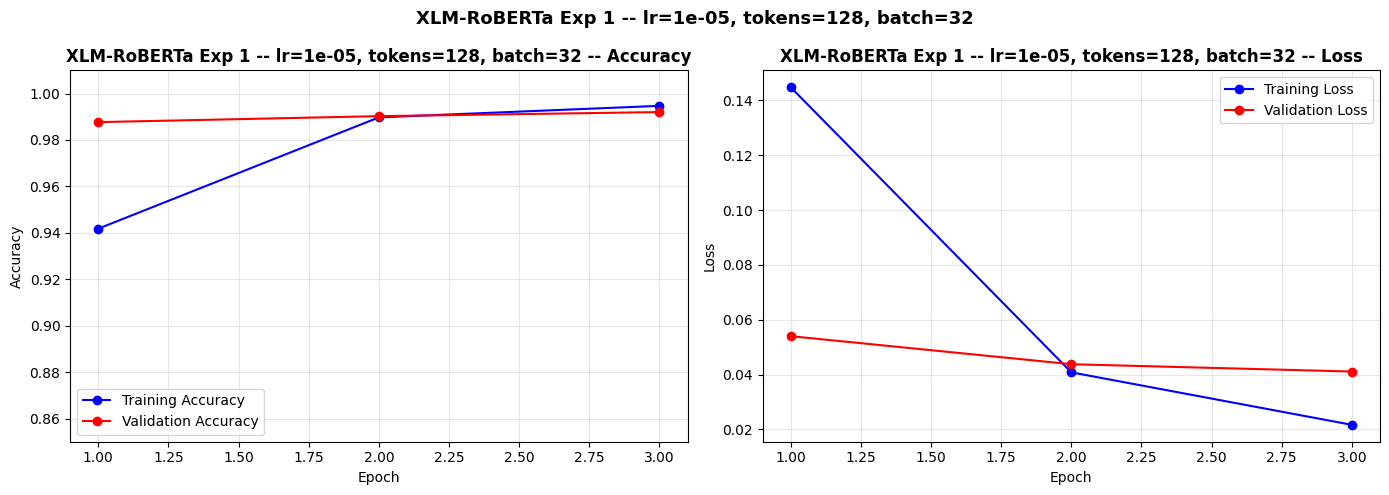

Saved: sweep_exp1_curves.png


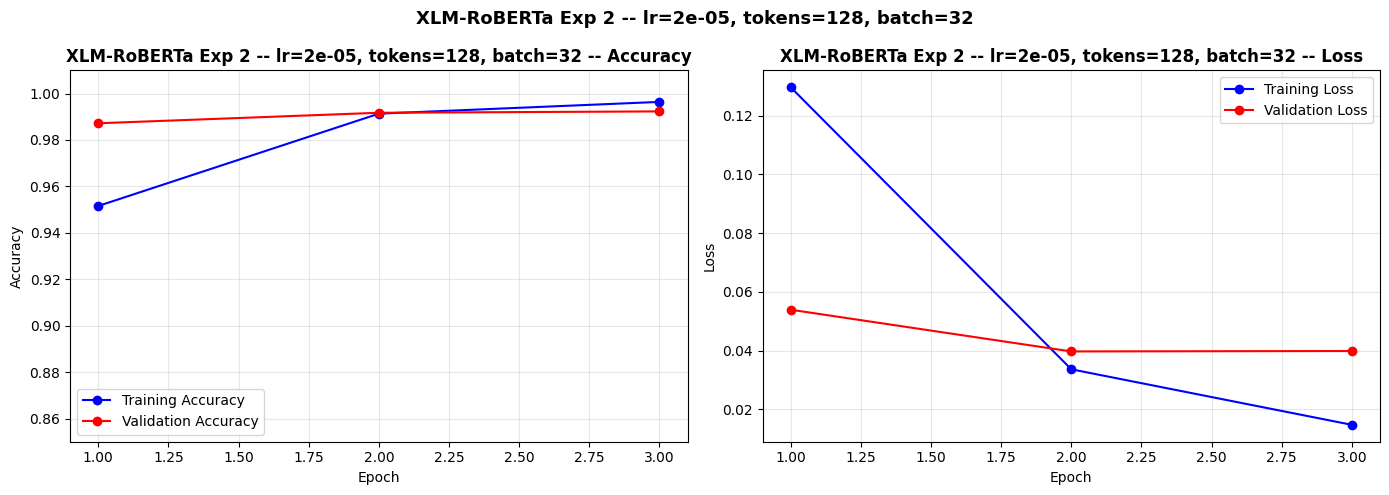

Saved: sweep_exp2_curves.png


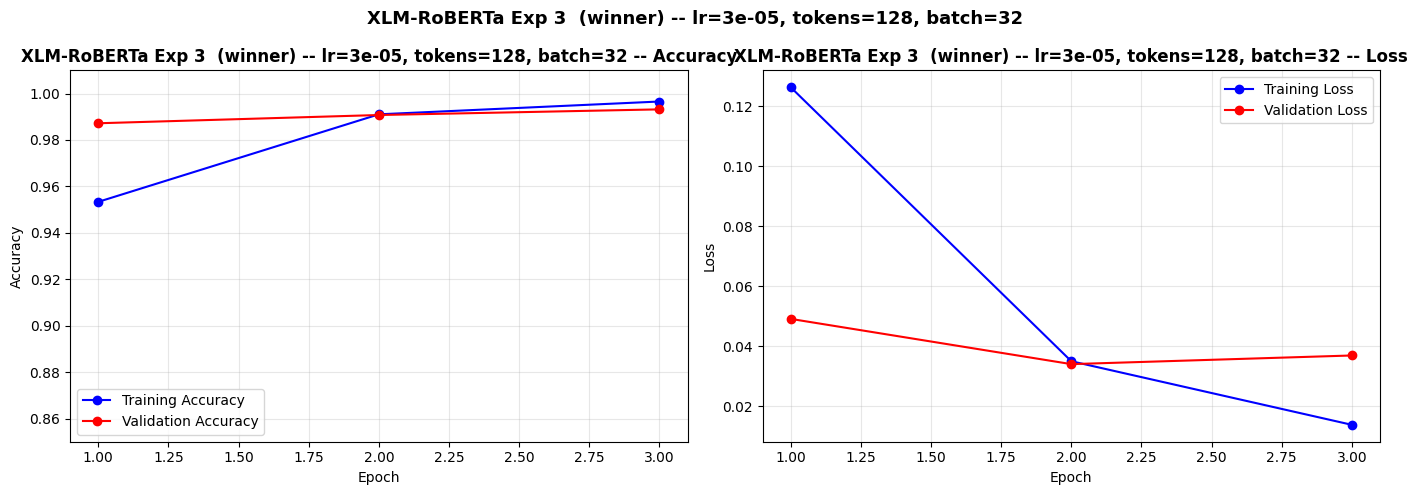

Saved: sweep_exp3_curves.png


In [10]:
# =============================================================================
# CELL 7c: Plot accuracy/loss curves for each of the 5 experiments -- separate
# figures, grouped together in this section as requested.
# =============================================================================
for cfg in sweep_configs:
    label = cfg['label']
    h = sweep_histories[label]
    suffix = '  (winner)' if label == best_sweep_label else ''
    plot_training_curves(
        h,
        title=f'XLM-RoBERTa {label}{suffix} -- lr={cfg["lr"]}, tokens={cfg["max_length"]}, batch={cfg["batch_size"]}',
        save_name=f'sweep_{label.lower().replace(" ", "")}_curves',
    )


In [11]:
# =============================================================================
# CELL 7d: Evaluate each of the 5 sweep models on the test set
# -----------------------------------------------------------------------------
sweep_test_results = {}

for cfg in sweep_configs:
    label = cfg['label']
    info  = sweep_checkpoints[label]
    model = build_model(XLM_MODEL_NAME, freeze_encoder=False)
    model.load_state_dict(torch.load(info['ckpt']))

    df_res, true_l, pred_l, prob_l, lang_l = evaluate_model(
        model, info['test_loader'], split_name='Test', run_name=info['run_name'], verbose=False
    )
    df_res['experiment'] = label
    sweep_test_results[label] = {
        'df': df_res, 'true': true_l, 'pred': pred_l, 'probs': prob_l, 'langs': lang_l
    }

    overall_f1 = df_res[df_res['language'] == 'overall']['f1'].values[0]
    print(f"{label:10s}  Test F1 = {overall_f1:.4f}")

    del model
    torch.cuda.empty_cache()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable
Exp 1       Test F1 = 0.9926


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable
Exp 2       Test F1 = 0.9927


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable
Exp 3       Test F1 = 0.9922


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable


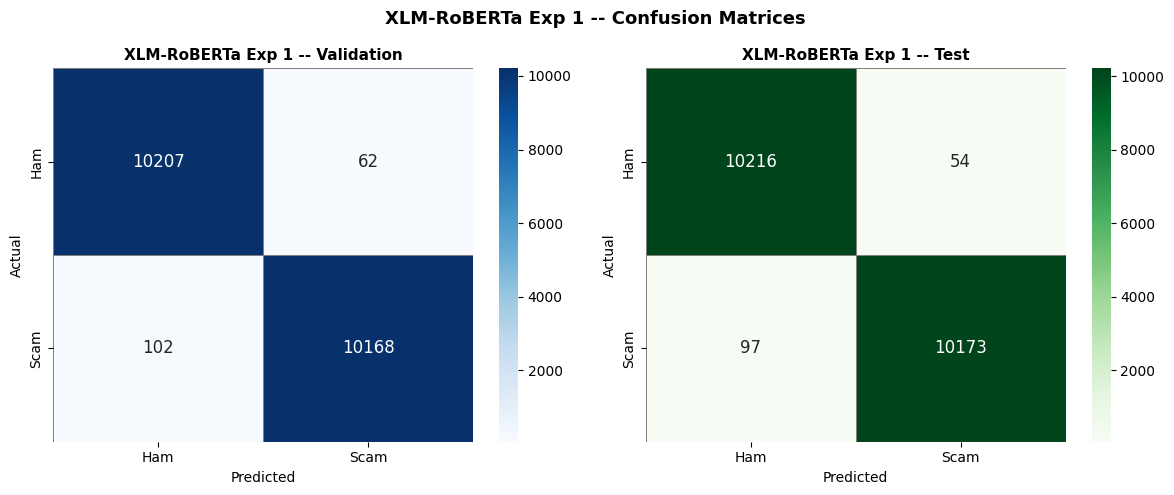

Saved: sweep_exp1_confusion.png


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable


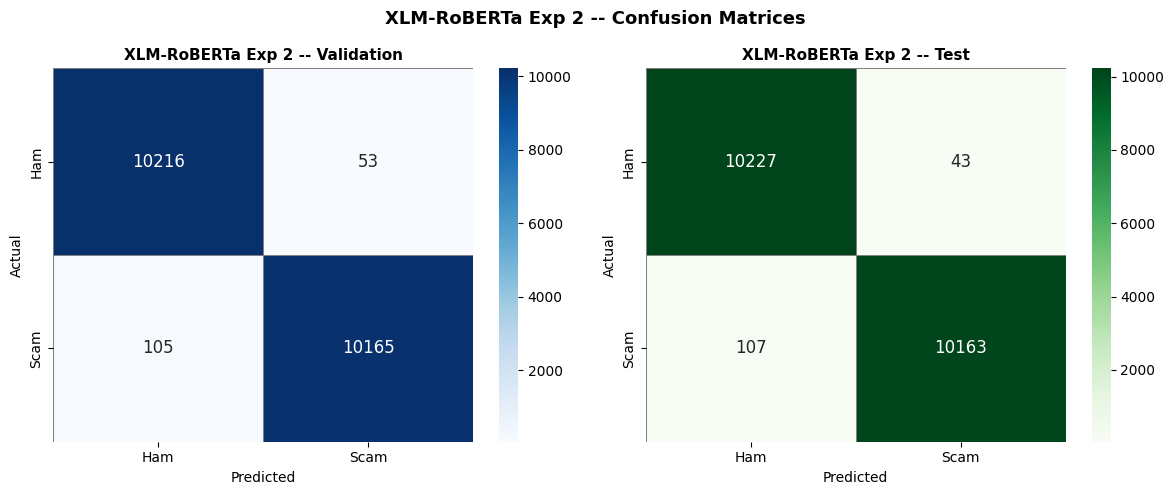

Saved: sweep_exp2_confusion.png


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable


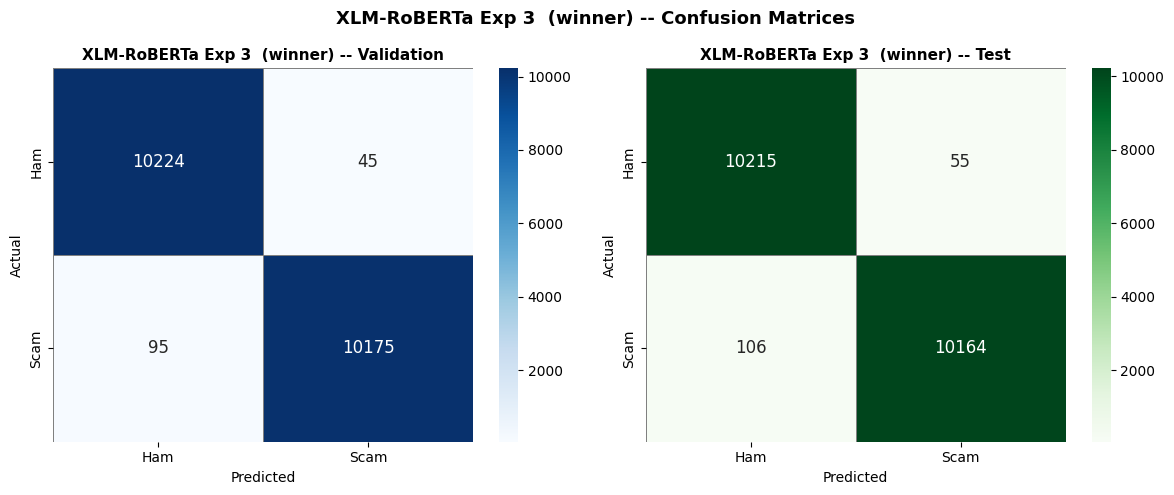

Saved: sweep_exp3_confusion.png


In [12]:
# =============================================================================
# CELL 7e: Confusion matrices for each of the 5 experiments -- grouped together
# =============================================================================
for cfg in sweep_configs:
    label = cfg['label']
    info  = sweep_checkpoints[label]
    res   = sweep_test_results[label]
    val_true = []
    val_pred = []
    # quick re-eval on val split for the confusion matrix (test split already cached above)
    model = build_model(XLM_MODEL_NAME, freeze_encoder=False)
    model.load_state_dict(torch.load(info['ckpt']))
    _, val_true, val_pred, _, _ = evaluate_model(
        model, info['val_loader'], split_name='Validation', run_name=info['run_name'], verbose=False
    )
    del model
    torch.cuda.empty_cache()

    suffix = '  (winner)' if label == best_sweep_label else ''
    plot_confusion_matrices(
        val_true, val_pred, res['true'], res['pred'],
        title=f'XLM-RoBERTa {label}{suffix}',
        save_name=f'sweep_{label.lower().replace(" ", "")}_confusion',
    )


## 8. WeightedRandomSampler experiment

Addresses English dominance in the training set by upsampling minority languages during
training. Sample weights are inversely proportional to language frequency. Uses the
**winning configuration from Section 7** (not a separate sweep), so this experiment isolates
the effect of the sampling strategy alone.


In [13]:
# =============================================================================
# CELL 8: WeightedRandomSampler experiment (uses WINNING_CONFIG)
# -----------------------------------------------------------------------------
from torch.utils.data import WeightedRandomSampler

print("="*65)
print(f"WEIGHTEDRANDOMSAMPLER EXPERIMENT  (using {best_sweep_label} config)")
print("="*65)

lang_counts  = df_train['language'].value_counts().to_dict()
total_train  = len(df_train)
lang_weights = {lang: total_train / count for lang, count in lang_counts.items()}
sample_weights = df_train['language'].map(lang_weights).values

print("Language counts in training set:")
for lang, count in sorted(lang_counts.items()):
    print(f"  {lang:10s}: {count:,}  (weight = {lang_weights[lang]:.2f})")

sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

# Re-tokenise with the winning config's max_length/batch_size for a fair comparison
wrs_tokenizer = AutoTokenizer.from_pretrained(XLM_MODEL_NAME)
wrs_train_ds  = ScamSenseDataset(df_train, wrs_tokenizer, WINNING_CONFIG['max_length'])

wrs_train_loader = DataLoader(
    wrs_train_ds, batch_size=WINNING_CONFIG['batch_size'], sampler=sampler,
    num_workers=2, pin_memory=True
)

# val/test loaders for the winning config are already cached from the sweep
wrs_val_loader  = sweep_checkpoints[best_sweep_label]['val_loader']
wrs_test_loader = sweep_checkpoints[best_sweep_label]['test_loader']

print(f"\nWeightedRandomSampler train loader: {len(wrs_train_loader)} batches")
print(f"Training XLM-RoBERTa with winning config (lr={WINNING_CONFIG['lr']}, "
      f"tokens={WINNING_CONFIG['max_length']}, batch={WINNING_CONFIG['batch_size']})...")

wrs_model = build_model(XLM_MODEL_NAME, freeze_encoder=False)
WRS_RUN   = 'xlmroberta-wrs'
WRS_CKPT, wrs_history = train_model(
    model=wrs_model, model_name=XLM_MODEL_NAME, run_name=WRS_RUN,
    train_loader=wrs_train_loader, val_loader=wrs_val_loader,
    epochs=SWEEP_EPOCHS, lr=WINNING_CONFIG['lr'],
    batch_size=WINNING_CONFIG['batch_size'], max_length=WINNING_CONFIG['max_length'],
)

print("\nEvaluating WRS model on test set...")
wrs_model.load_state_dict(torch.load(WRS_CKPT))
df_wrs_test, wrs_test_true, wrs_test_preds, wrs_test_probs, wrs_test_langs = evaluate_model(
    wrs_model, wrs_test_loader, split_name='Test', run_name=WRS_RUN
)
df_wrs_test['experiment'] = 'WRS'

_, wrs_val_true, wrs_val_preds, _, _ = evaluate_model(
    wrs_model, wrs_val_loader, split_name='Validation', run_name=WRS_RUN, verbose=False
)

del wrs_model
torch.cuda.empty_cache()


WEIGHTEDRANDOMSAMPLER EXPERIMENT  (using Exp 3 config)
Language counts in training set:
  en        : 68,730  (weight = 1.39)
  ms        : 6,682  (weight = 14.34)
  singlish  : 7,000  (weight = 13.69)
  ta        : 6,492  (weight = 14.76)
  zh        : 6,947  (weight = 13.80)

WeightedRandomSampler train loader: 2996 batches
Training XLM-RoBERTa with winning config (lr=3e-05, tokens=128, batch=32)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable

  MODEL : xlm-roberta-base
  RUN   : xlmroberta-wrs
  LR=3e-05 | Batch=32 | Epochs=3



  Ep1 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 1/3  [842s]
  Train Loss : 0.0775  |  Train Acc: 0.9712  |  Train F1: 0.9712
  Val Loss   : 0.0914  |  Val Acc:   0.9819  |  Val F1:   0.9819
  Precision  : 0.9819  |  Recall:    0.9819  |  LR:       2.22e-05
  Val F1 improved (-inf -> 0.9819) -- checkpoint saved



  Ep2 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 2/3  [841s]
  Train Loss : 0.0195  |  Train Acc: 0.9950  |  Train F1: 0.9950
  Val Loss   : 0.0652  |  Val Acc:   0.9851  |  Val F1:   0.9851
  Precision  : 0.9851  |  Recall:    0.9851  |  LR:       1.11e-05
  Val F1 improved (0.9819 -> 0.9851) -- checkpoint saved



  Ep3 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 3/3  [840s]
  Train Loss : 0.0103  |  Train Acc: 0.9974  |  Train F1: 0.9974
  Val Loss   : 0.0529  |  Val Acc:   0.9890  |  Val F1:   0.9890
  Precision  : 0.9890  |  Recall:    0.9890  |  LR:       0.00e+00
  Val F1 improved (0.9851 -> 0.9890) -- checkpoint saved

🏃 View run xlmroberta-wrs at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/bf88681a182d41a78b2eb87ec8970610
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0
  Training complete -- Best Val F1: 0.9890
  Checkpoint: /kaggle/working/models/xlmroberta-wrs_best.pt

Evaluating WRS model on test set...

  xlmroberta-wrs -- Test Results
  Loss      : 0.0527
  Accuracy  : 0.9887  (98.87%)
  Precision : 0.9887
  Recall    : 0.9887
  F1-Score  : 0.9887
  AUC-ROC   : 0.9986

Classification Report (Test):

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99     10270
        Scam       0.99      0.98      0.99     10270

    acc

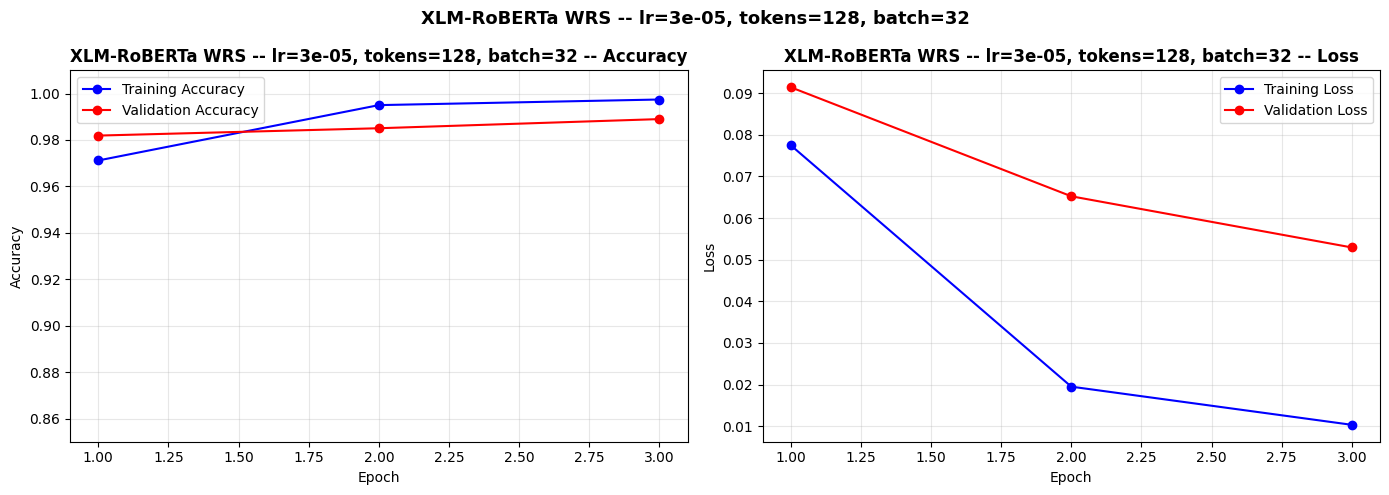

Saved: wrs_curves.png


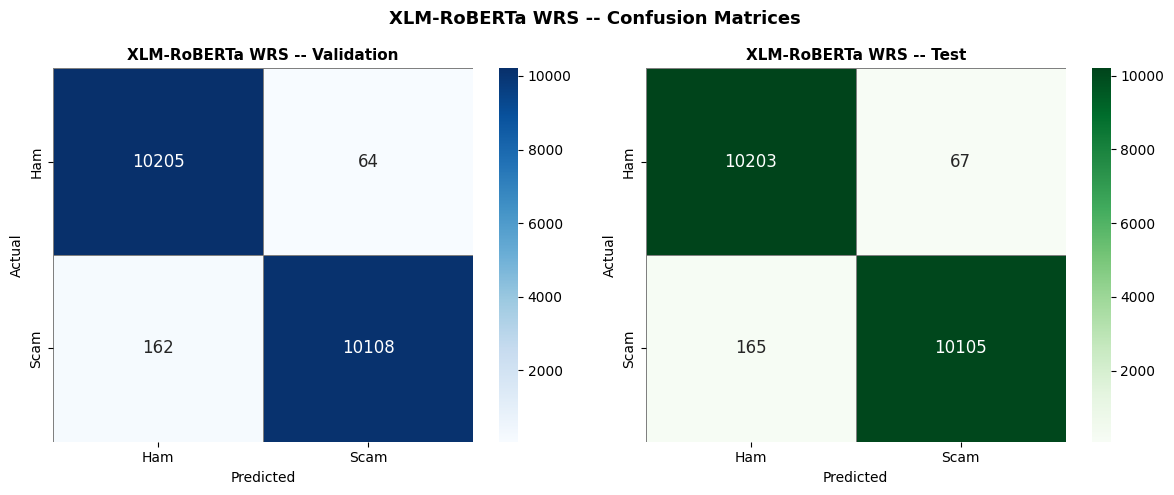

Saved: wrs_confusion.png


In [14]:
# =============================================================================
# CELL 8a: WRS -- training curves and confusion matrix
# =============================================================================
plot_training_curves(
    wrs_history,
    title=f'XLM-RoBERTa WRS -- lr={WINNING_CONFIG["lr"]}, tokens={WINNING_CONFIG["max_length"]}, batch={WINNING_CONFIG["batch_size"]}',
    save_name='wrs_curves',
)
plot_confusion_matrices(
    wrs_val_true, wrs_val_preds, wrs_test_true, wrs_test_preds,
    title='XLM-RoBERTa WRS', save_name='wrs_confusion',
)


In [15]:
# =============================================================================
# CELL 8b: WRS vs the winning sweep config -- per-language F1 comparison
# =============================================================================
df_winner_test = sweep_test_results[best_sweep_label]['df']
df_winner_lang = df_winner_test[df_winner_test['language'] != 'overall'][['language', 'f1']].rename(
    columns={'f1': f'f1_{best_sweep_label.lower().replace(" ", "")}'})
df_wrs_lang = df_wrs_test[df_wrs_test['language'] != 'overall'][['language', 'f1']].rename(columns={'f1': 'f1_wrs'})

comparison_wrs = df_winner_lang.merge(df_wrs_lang, on='language')
winner_col = f'f1_{best_sweep_label.lower().replace(" ", "")}'
comparison_wrs['delta'] = (comparison_wrs['f1_wrs'] - comparison_wrs[winner_col]).round(4)

print(f"\n=== WeightedRandomSampler vs {best_sweep_label} (winning config, no sampling change) ===\n")
print(comparison_wrs.to_string(index=False))
comparison_wrs.to_csv(f'{OUTPUT_DIR}/wrs_vs_winner.csv', index=False)
print(f"\nSaved: wrs_vs_winner.csv")

winner_overall = df_winner_test[df_winner_test['language'] == 'overall']['f1'].values[0]
wrs_overall    = df_wrs_test[df_wrs_test['language'] == 'overall']['f1'].values[0]
print(f"\nOverall F1 -- {best_sweep_label}: {winner_overall:.4f}  |  WRS: {wrs_overall:.4f}  "
      f"|  Delta: {wrs_overall - winner_overall:+.4f}")



=== WeightedRandomSampler vs Exp 3 (winning config, no sampling change) ===

language  f1_exp3  f1_wrs   delta
      en   0.9894  0.9845 -0.0049
      ms   1.0000  1.0000  0.0000
singlish   0.9980  0.9980  0.0000
      ta   0.9986  0.9993  0.0007
      zh   1.0000  1.0000  0.0000

Saved: wrs_vs_winner.csv

Overall F1 -- Exp 3: 0.9922  |  WRS: 0.9887  |  Delta: -0.0035


## 9. Text normalisation experiment

Tests whether normalising text (URL -> `[URL]`, amount -> `[AMOUNT]`, emoji removal -- applied
in NB02 Section 2.8) improves F1 relative to raw text. Uses the **same winning configuration**
from Section 7, so only the preprocessing strategy is varied.


In [16]:
# =============================================================================
# CELL 9: Text normalisation experiment (uses WINNING_CONFIG)
# -----------------------------------------------------------------------------
print("="*65)
print(f"TEXT NORMALISATION EXPERIMENT  (using {best_sweep_label} config)")
print("="*65)

def load_norm_split(filename):
    kaggle_path  = f'{INPUT_DIR}/{filename}'
    working_path = f'{OUTPUT_DIR}/{filename}'
    if os.path.exists(kaggle_path):
        return pd.read_csv(kaggle_path, encoding='utf-8-sig')
    elif os.path.exists(working_path):
        return pd.read_csv(working_path, encoding='utf-8-sig')
    else:
        raise FileNotFoundError(f'{filename} not found. Run NB02 Section 2.8 first.')

df_train_norm = load_norm_split('train_norm.csv').dropna(subset=['text']).reset_index(drop=True)
df_val_norm   = load_norm_split('val_norm.csv').dropna(subset=['text']).reset_index(drop=True)
df_test_norm  = load_norm_split('test_norm.csv').dropna(subset=['text']).reset_index(drop=True)

print(f"Normalised splits loaded: train={len(df_train_norm):,} | val={len(df_val_norm):,} | test={len(df_test_norm):,}")

norm_tokenizer, norm_train_loader, norm_val_loader, norm_test_loader = build_loaders(
    XLM_MODEL_NAME,
    max_length=WINNING_CONFIG['max_length'],
    batch_size=WINNING_CONFIG['batch_size'],
    train_df=df_train_norm, val_df=df_val_norm, test_df=df_test_norm,
)

print(f"Training XLM-RoBERTa on normalised dataset with winning config "
      f"(lr={WINNING_CONFIG['lr']}, tokens={WINNING_CONFIG['max_length']}, batch={WINNING_CONFIG['batch_size']})...")

norm_model = build_model(XLM_MODEL_NAME, freeze_encoder=False)
NORM_RUN   = 'xlmroberta-normalised'
NORM_CKPT, norm_history = train_model(
    model=norm_model, model_name=XLM_MODEL_NAME, run_name=NORM_RUN,
    train_loader=norm_train_loader, val_loader=norm_val_loader,
    epochs=SWEEP_EPOCHS, lr=WINNING_CONFIG['lr'],
    batch_size=WINNING_CONFIG['batch_size'], max_length=WINNING_CONFIG['max_length'],
)

print("\nEvaluating normalised model on test set...")
norm_model.load_state_dict(torch.load(NORM_CKPT))
df_norm_test, norm_test_true, norm_test_preds, norm_test_probs, norm_test_langs = evaluate_model(
    norm_model, norm_test_loader, split_name='Test', run_name=NORM_RUN
)
df_norm_test['experiment'] = 'Text-Norm'

_, norm_val_true, norm_val_preds, _, _ = evaluate_model(
    norm_model, norm_val_loader, split_name='Validation', run_name=NORM_RUN, verbose=False
)

del norm_model
torch.cuda.empty_cache()


TEXT NORMALISATION EXPERIMENT  (using Exp 3 config)
Normalised splits loaded: train=95,851 | val=20,539 | test=20,540
Tokenising with xlm-roberta-base  (max_length=128, batch_size=32)...
Loaders ready: 2996 train batches
Training XLM-RoBERTa on normalised dataset with winning config (lr=3e-05, tokens=128, batch=32)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable

  MODEL : xlm-roberta-base
  RUN   : xlmroberta-normalised
  LR=3e-05 | Batch=32 | Epochs=3



  Ep1 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 1/3  [846s]
  Train Loss : 0.1348  |  Train Acc: 0.9491  |  Train F1: 0.9491
  Val Loss   : 0.0654  |  Val Acc:   0.9875  |  Val F1:   0.9875
  Precision  : 0.9875  |  Recall:    0.9875  |  LR:       2.22e-05
  Val F1 improved (-inf -> 0.9875) -- checkpoint saved



  Ep2 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 2/3  [844s]
  Train Loss : 0.0380  |  Train Acc: 0.9903  |  Train F1: 0.9903
  Val Loss   : 0.0429  |  Val Acc:   0.9903  |  Val F1:   0.9903
  Precision  : 0.9904  |  Recall:    0.9903  |  LR:       1.11e-05
  Val F1 improved (0.9875 -> 0.9903) -- checkpoint saved



  Ep3 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 3/3  [844s]
  Train Loss : 0.0159  |  Train Acc: 0.9962  |  Train F1: 0.9962
  Val Loss   : 0.0354  |  Val Acc:   0.9926  |  Val F1:   0.9926
  Precision  : 0.9926  |  Recall:    0.9926  |  LR:       0.00e+00
  Val F1 improved (0.9903 -> 0.9926) -- checkpoint saved

🏃 View run xlmroberta-normalised at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/50eb36b3eaf0459c9f1d0a5d5b2d0b9f
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0
  Training complete -- Best Val F1: 0.9926
  Checkpoint: /kaggle/working/models/xlmroberta-normalised_best.pt

Evaluating normalised model on test set...

  xlmroberta-normalised -- Test Results
  Loss      : 0.0423
  Accuracy  : 0.9918  (99.18%)
  Precision : 0.9918
  Recall    : 0.9918
  F1-Score  : 0.9918
  AUC-ROC   : 0.9986

Classification Report (Test):

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99     10270
        Scam       0.99      0.99 

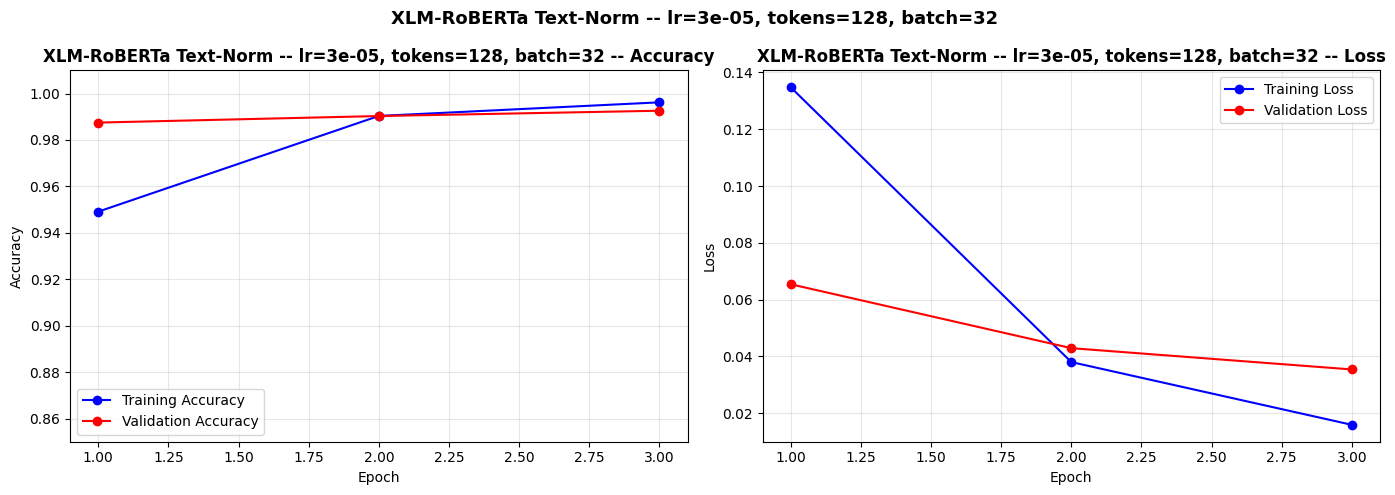

Saved: textnorm_curves.png


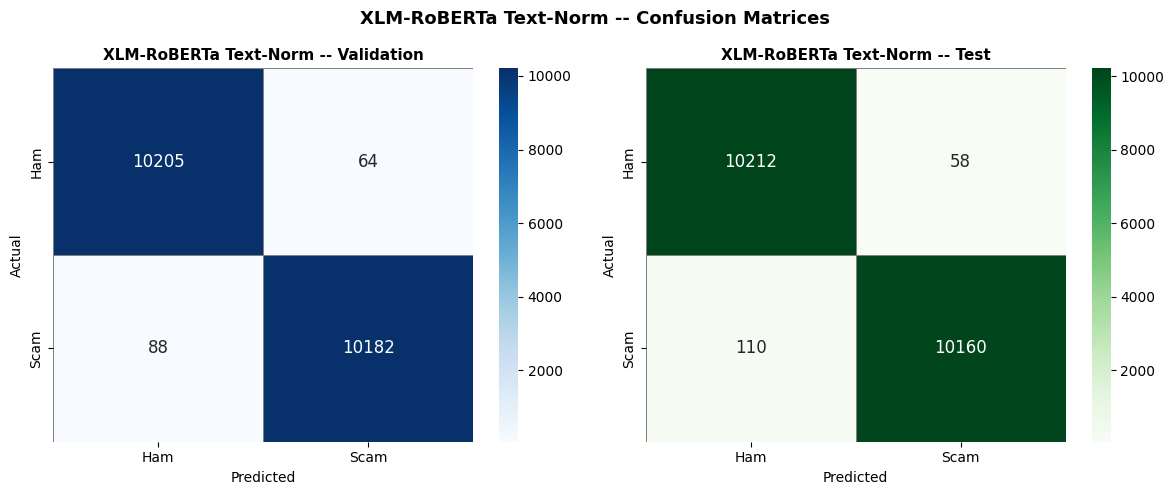

Saved: textnorm_confusion.png


In [17]:
# =============================================================================
# CELL 9a: Text-normalisation -- training curves and confusion matrix
# =============================================================================
plot_training_curves(
    norm_history,
    title=f'XLM-RoBERTa Text-Norm -- lr={WINNING_CONFIG["lr"]}, tokens={WINNING_CONFIG["max_length"]}, batch={WINNING_CONFIG["batch_size"]}',
    save_name='textnorm_curves',
)
plot_confusion_matrices(
    norm_val_true, norm_val_preds, norm_test_true, norm_test_preds,
    title='XLM-RoBERTa Text-Norm', save_name='textnorm_confusion',
)


In [18]:
# =============================================================================
# CELL 9b: Raw (winning config) vs Normalised -- per-language F1 comparison
# =============================================================================
df_raw_lang  = df_winner_test[df_winner_test['language'] != 'overall'][['language', 'f1']].rename(columns={'f1': 'f1_raw'})
df_norm_lang = df_norm_test[df_norm_test['language'] != 'overall'][['language', 'f1']].rename(columns={'f1': 'f1_norm'})

comparison_norm = df_raw_lang.merge(df_norm_lang, on='language')
comparison_norm['delta'] = (comparison_norm['f1_norm'] - comparison_norm['f1_raw']).round(4)

raw_overall  = winner_overall
norm_overall = df_norm_test[df_norm_test['language'] == 'overall']['f1'].values[0]

print("\n=== Raw (winning config) vs Normalised -- Per-Language F1 ===")
print(comparison_norm.to_string(index=False))
print(f"\nOverall F1 -- Raw: {raw_overall:.4f}  |  Normalised: {norm_overall:.4f}  "
      f"|  Delta: {norm_overall - raw_overall:+.4f}")
comparison_norm.to_csv(f'{OUTPUT_DIR}/normalised_vs_raw.csv', index=False)
print(f"Saved: normalised_vs_raw.csv")



=== Raw (winning config) vs Normalised -- Per-Language F1 ===
language  f1_raw  f1_norm   delta
      en  0.9894   0.9890 -0.0004
      ms  1.0000   1.0000  0.0000
singlish  0.9980   0.9973 -0.0007
      ta  0.9986   0.9986  0.0000
      zh  1.0000   1.0000  0.0000

Overall F1 -- Raw: 0.9922  |  Normalised: 0.9918  |  Delta: -0.0004
Saved: normalised_vs_raw.csv


## 10. Consolidated XLM-RoBERTa comparison -- all 5 variants

Combines Exp 1-3, WRS, and Text-Norm into a single results table and a single F1-per-language
bar chart, so the full set of XLM-RoBERTa experiments can be read at a glance.


In [19]:
# =============================================================================
# CELL 10: Combine all 5 XLM-RoBERTa variants into one table + one chart
# -----------------------------------------------------------------------------
all_xlm_dfs = []
for cfg in sweep_configs:
    label = cfg['label']
    df_e = sweep_test_results[label]['df'].copy()
    df_e['experiment'] = label
    all_xlm_dfs.append(df_e)

all_xlm_dfs.append(df_wrs_test.copy())
all_xlm_dfs.append(df_norm_test.copy())

df_xlm_all = pd.concat(all_xlm_dfs, ignore_index=True)
df_xlm_all.to_csv(f'{OUTPUT_DIR}/xlmroberta_all_experiments.csv', index=False)

print("All 5 XLM-RoBERTa experiments -- overall metrics:")
print(df_xlm_all[df_xlm_all['language'] == 'overall'][['experiment', 'accuracy', 'precision', 'recall', 'f1', 'auc']]
      .sort_values('f1', ascending=False).to_string(index=False))
print(f"\nSaved: xlmroberta_all_experiments.csv")


All 5 XLM-RoBERTa experiments -- overall metrics:
experiment  accuracy  precision  recall     f1    auc
     Exp 2    0.9927     0.9927  0.9927 0.9927 0.9988
     Exp 1    0.9926     0.9927  0.9926 0.9926 0.9990
     Exp 3    0.9922     0.9922  0.9922 0.9922 0.9991
 Text-Norm    0.9918     0.9918  0.9918 0.9918 0.9986
       WRS    0.9887     0.9887  0.9887 0.9887 0.9986

Saved: xlmroberta_all_experiments.csv


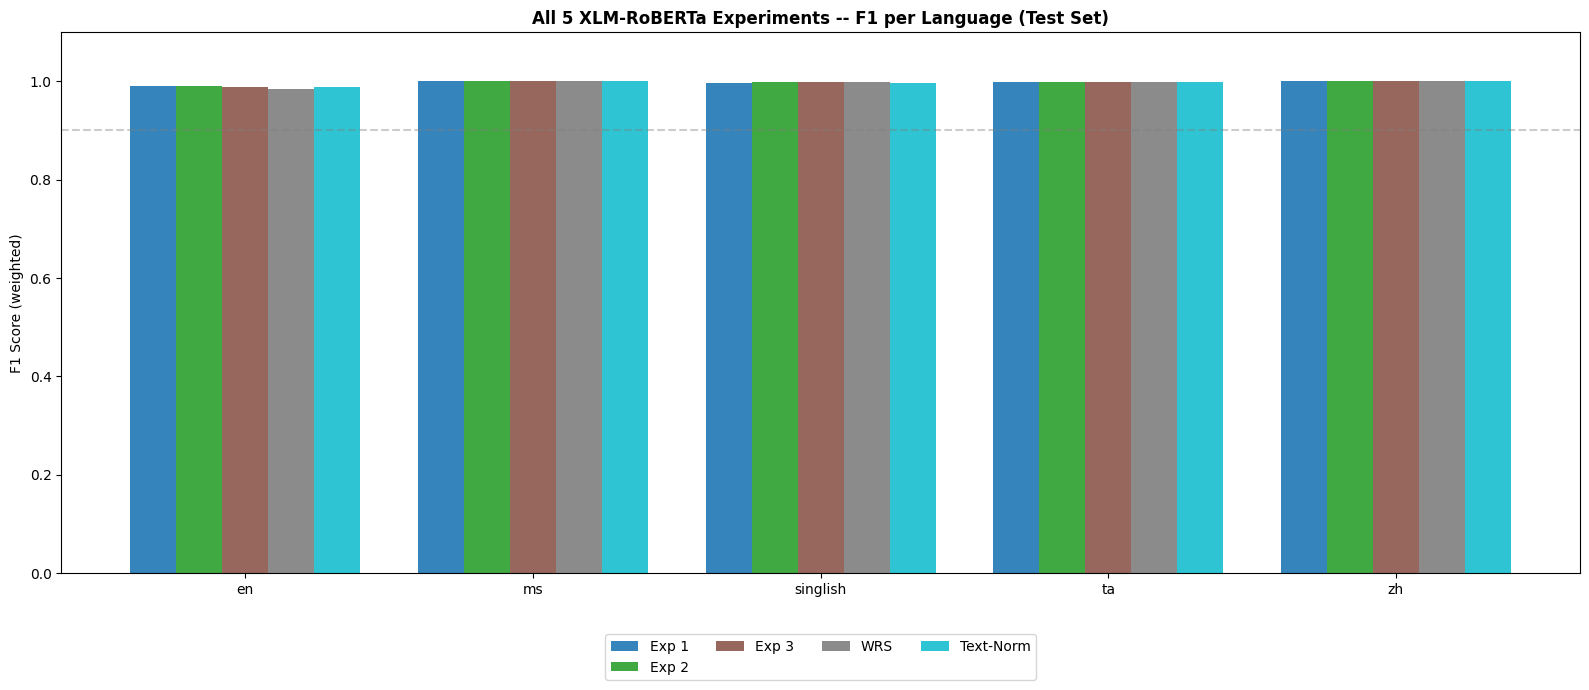

Saved: xlmroberta_all_experiments_f1.png

Best XLM-RoBERTa variant overall: Exp 2  (F1: 0.9927)


In [20]:
# =============================================================================
# CELL 10a: F1-per-language bar chart -- all 5 XLM-RoBERTa experiments
# =============================================================================
df_xlm_lang_all = df_xlm_all[df_xlm_all['language'] != 'overall'].copy()
languages_all = sorted(df_xlm_lang_all['language'].unique())
experiments_all = [cfg['label'] for cfg in sweep_configs] + ['WRS', 'Text-Norm']
x = np.arange(len(languages_all))
n_exp = len(experiments_all)
w = 0.8 / n_exp

colors = plt.cm.tab10(np.linspace(0, 1, n_exp))

fig, ax = plt.subplots(figsize=(16, 7))
for i, (exp, color) in enumerate(zip(experiments_all, colors)):
    f1_vals = [
        df_xlm_lang_all[(df_xlm_lang_all['experiment'] == exp) & (df_xlm_lang_all['language'] == lang)]['f1'].values[0]
        if len(df_xlm_lang_all[(df_xlm_lang_all['experiment'] == exp) & (df_xlm_lang_all['language'] == lang)]) > 0 else 0
        for lang in languages_all
    ]
    ax.bar(x + i * w - (n_exp - 1) * w / 2, f1_vals, width=w, label=exp, color=color, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(languages_all)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score (weighted)')
ax.set_title('All 5 XLM-RoBERTa Experiments -- F1 per Language (Test Set)', fontweight='bold')
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.1))
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xlmroberta_all_experiments_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xlmroberta_all_experiments_f1.png')

# Best XLM-R variant overall
df_xlm_overall = df_xlm_all[df_xlm_all['language'] == 'overall']
best_xlm_experiment = df_xlm_overall.loc[df_xlm_overall['f1'].idxmax(), 'experiment']
best_xlm_f1          = df_xlm_overall['f1'].max()
print(f"\nBest XLM-RoBERTa variant overall: {best_xlm_experiment}  (F1: {best_xlm_f1:.4f})")


## 11. mBERT baseline (trained once)

mBERT is trained **once**, as a frozen-encoder baseline, using the **token length and batch
size** from the winning XLM-RoBERTa configuration (Section 7) for a fair, consistent input
representation across both architectures.

The learning rate is kept separate from the XLM-RoBERTa winner: mBERT here uses a **frozen
encoder** (only the classification head is trainable), and frozen heads typically need a much
higher learning rate to converge in a small number of epochs than a fully fine-tuned encoder
does. Reusing the XLM-RoBERTa winner's lr (e.g. 1e-5 to 3e-5) would almost certainly
under-train the head. `MBERT_LR = 1e-3` is used instead, consistent with standard practice for
frozen-encoder linear-probe baselines.


In [21]:
# =============================================================================
# CELL 11: Build and train mBERT (frozen baseline, trained once)
# -----------------------------------------------------------------------------
MBERT_MODEL_NAME = 'bert-base-multilingual-cased'
MBERT_RUN_NAME    = 'mbert-scamsense-baseline'
MBERT_LR          = 1e-3  # frozen encoder needs a higher lr than full fine-tune; see note above

mbert_tokenizer, mbert_train_loader, mbert_val_loader, mbert_test_loader = build_loaders(
    MBERT_MODEL_NAME,
    max_length=WINNING_CONFIG['max_length'],
    batch_size=WINNING_CONFIG['batch_size'],
)

mbert_model = build_model(MBERT_MODEL_NAME, freeze_encoder=True)
total_params     = sum(p.numel() for p in mbert_model.parameters())
trainable_params = sum(p.numel() for p in mbert_model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.3f}%)")
print(f"Token length / batch reused from winning config ({best_sweep_label}): "
      f"{WINNING_CONFIG['max_length']} tokens, batch {WINNING_CONFIG['batch_size']}")
print(f"Track at: https://dagshub.com/Bhoovika/ScamSense.mlflow\n")

MBERT_CKPT, mbert_history = train_model(
    model=mbert_model, model_name=MBERT_MODEL_NAME, run_name=MBERT_RUN_NAME,
    train_loader=mbert_train_loader, val_loader=mbert_val_loader,
    epochs=SWEEP_EPOCHS, lr=MBERT_LR, freeze_encoder=True,
    batch_size=WINNING_CONFIG['batch_size'], max_length=WINNING_CONFIG['max_length'],
)


Tokenising with bert-base-multilingual-cased  (max_length=128, batch_size=32)...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 1/3  [198s]
  Train Loss : 0.3260  |  Train Acc: 0.8559  |  Train F1: 0.8559
  Val Loss   : 0.2027  |  Val Acc:   0.9196  |  Val F1:   0.9195
  Precision  : 0.9210  |  Recall:    0.9196  |  LR:       7.41e-04
  Val F1 improved (-inf -> 0.9195) -- checkpoint saved



  Ep2 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 2/3  [197s]
  Train Loss : 0.2304  |  Train Acc: 0.9050  |  Train F1: 0.9050
  Val Loss   : 0.1700  |  Val Acc:   0.9336  |  Val F1:   0.9336
  Precision  : 0.9336  |  Recall:    0.9336  |  LR:       3.70e-04
  Val F1 improved (0.9195 -> 0.9336) -- checkpoint saved



  Ep3 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 3/3  [198s]
  Train Loss : 0.2015  |  Train Acc: 0.9177  |  Train F1: 0.9177
  Val Loss   : 0.1586  |  Val Acc:   0.9398  |  Val F1:   0.9398
  Precision  : 0.9399  |  Recall:    0.9398  |  LR:       0.00e+00
  Val F1 improved (0.9336 -> 0.9398) -- checkpoint saved

🏃 View run mbert-scamsense-baseline at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/f46a56bbfb3545f9a8a083e36d8ad7dd
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0
  Training complete -- Best Val F1: 0.9398
  Checkpoint: /kaggle/working/models/mbert-scamsense-baseline_best.pt


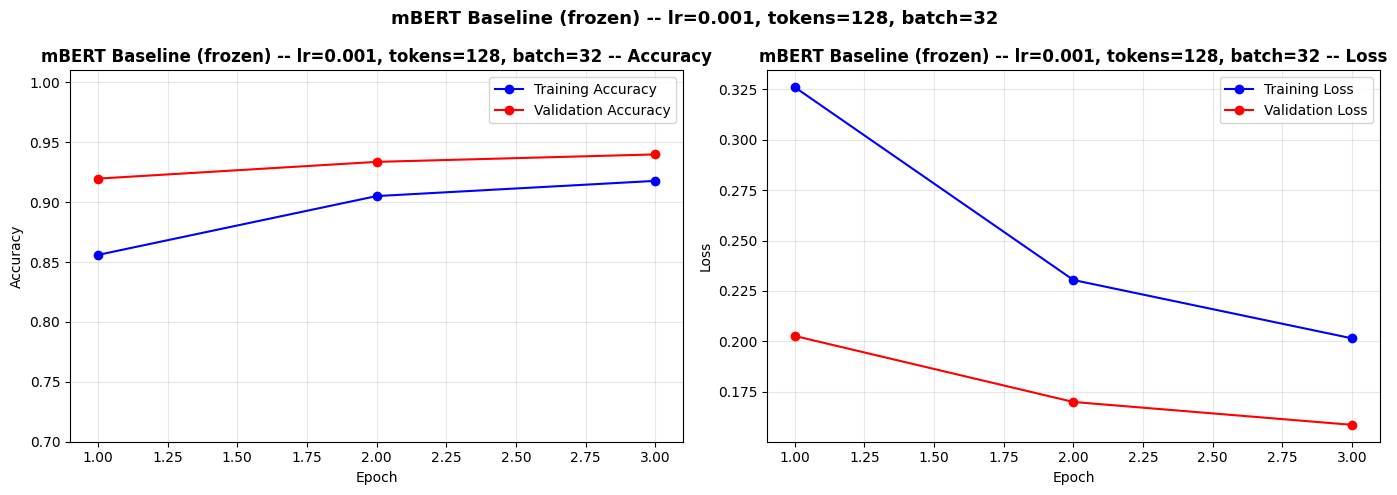

Saved: mbert_curves.png


In [22]:
# =============================================================================
# CELL 11a: mBERT -- training curves
# =============================================================================
plot_training_curves(
    mbert_history,
    title=f'mBERT Baseline (frozen) -- lr={MBERT_LR}, tokens={WINNING_CONFIG["max_length"]}, batch={WINNING_CONFIG["batch_size"]}',
    save_name='mbert_curves', acc_ylim=(0.7, 1.01),
)


In [23]:
# =============================================================================
# CELL 11b: mBERT -- validation and test evaluation
# =============================================================================
mbert_model.load_state_dict(torch.load(MBERT_CKPT))

df_mbert_val, mbert_val_true, mbert_val_preds, mbert_val_probs, mbert_val_langs = evaluate_model(
    mbert_model, mbert_val_loader, split_name='Validation', run_name=MBERT_RUN_NAME, verbose=False
)
df_mbert_test, mbert_test_true, mbert_test_preds, mbert_test_probs, mbert_test_langs = evaluate_model(
    mbert_model, mbert_test_loader, split_name='Test', run_name=MBERT_RUN_NAME
)
df_mbert_test['experiment'] = 'mBERT'



  mbert-scamsense-baseline -- Test Results
  Loss      : 0.1572
  Accuracy  : 0.9407  (94.07%)
  Precision : 0.9407
  Recall    : 0.9407
  F1-Score  : 0.9407
  AUC-ROC   : 0.9850

Classification Report (Test):

              precision    recall  f1-score   support

         Ham       0.94      0.94      0.94     10270
        Scam       0.94      0.94      0.94     10270

    accuracy                           0.94     20540
   macro avg       0.94      0.94      0.94     20540
weighted avg       0.94      0.94      0.94     20540

  en        : Acc=0.9193  Prec=0.9194  Rec=0.9193  F1=0.9193  AUC=0.9722
  ms        : Acc=0.9993  Prec=0.9993  Rec=0.9993  F1=0.9993  AUC=1.0000
  singlish  : Acc=0.9840  Prec=0.9842  Rec=0.9840  F1=0.9840  AUC=0.9996
  ta        : Acc=0.9986  Prec=0.9986  Rec=0.9986  F1=0.9986  AUC=1.0000
  zh        : Acc=0.9980  Prec=0.9980  Rec=0.9980  F1=0.9980  AUC=1.0000


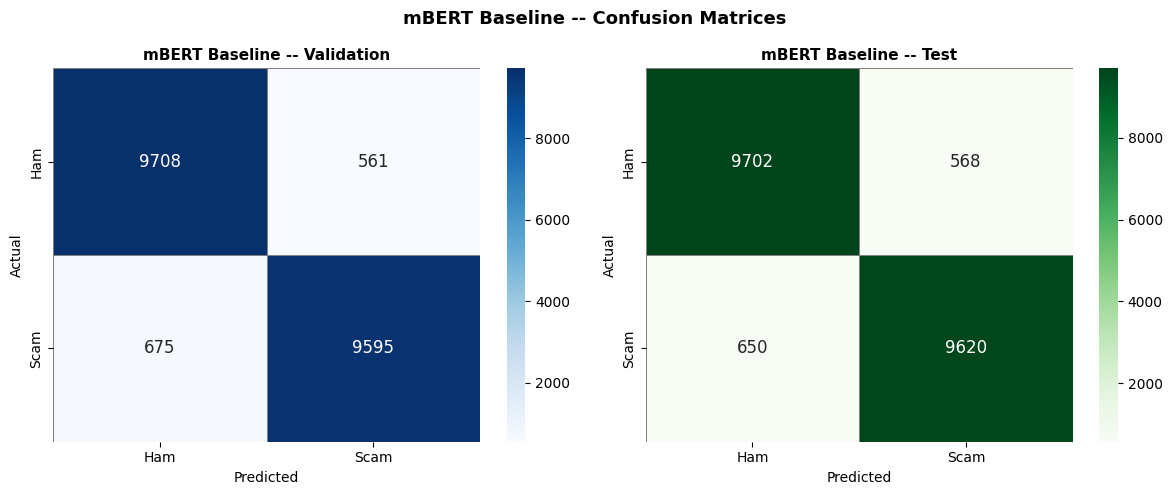

Saved: mbert_confusion.png


In [24]:
# =============================================================================
# CELL 11c: mBERT -- confusion matrices
# =============================================================================
plot_confusion_matrices(
    mbert_val_true, mbert_val_preds, mbert_test_true, mbert_test_preds,
    title='mBERT Baseline', save_name='mbert_confusion',
)


## 12. Final comparison: best XLM-RoBERTa vs mBERT

Compares the single best XLM-RoBERTa variant (selected from all 5 experiments in Section 10)
against the mBERT baseline, and selects the overall best model for export.


Final comparison table (best XLM-RoBERTa variant vs mBERT):
              model language  accuracy  precision  recall     f1    auc
XLM-RoBERTa (Exp 2)  overall    0.9927     0.9927  0.9927 0.9927 0.9988
XLM-RoBERTa (Exp 2)       en    0.9901     0.9901  0.9901 0.9901 0.9981
XLM-RoBERTa (Exp 2)       ms    1.0000     1.0000  1.0000 1.0000 1.0000
XLM-RoBERTa (Exp 2) singlish    0.9993     0.9993  0.9993 0.9993 1.0000
XLM-RoBERTa (Exp 2)       ta    0.9978     0.9979  0.9978 0.9978 1.0000
XLM-RoBERTa (Exp 2)       zh    1.0000     1.0000  1.0000 1.0000 1.0000
              mBERT  overall    0.9407     0.9407  0.9407 0.9407 0.9850
              mBERT       en    0.9193     0.9194  0.9193 0.9193 0.9722
              mBERT       ms    0.9993     0.9993  0.9993 0.9993 1.0000
              mBERT singlish    0.9840     0.9842  0.9840 0.9840 0.9996
              mBERT       ta    0.9986     0.9986  0.9986 0.9986 1.0000
              mBERT       zh    0.9980     0.9980  0.9980 0.9980 1.0000

Sav

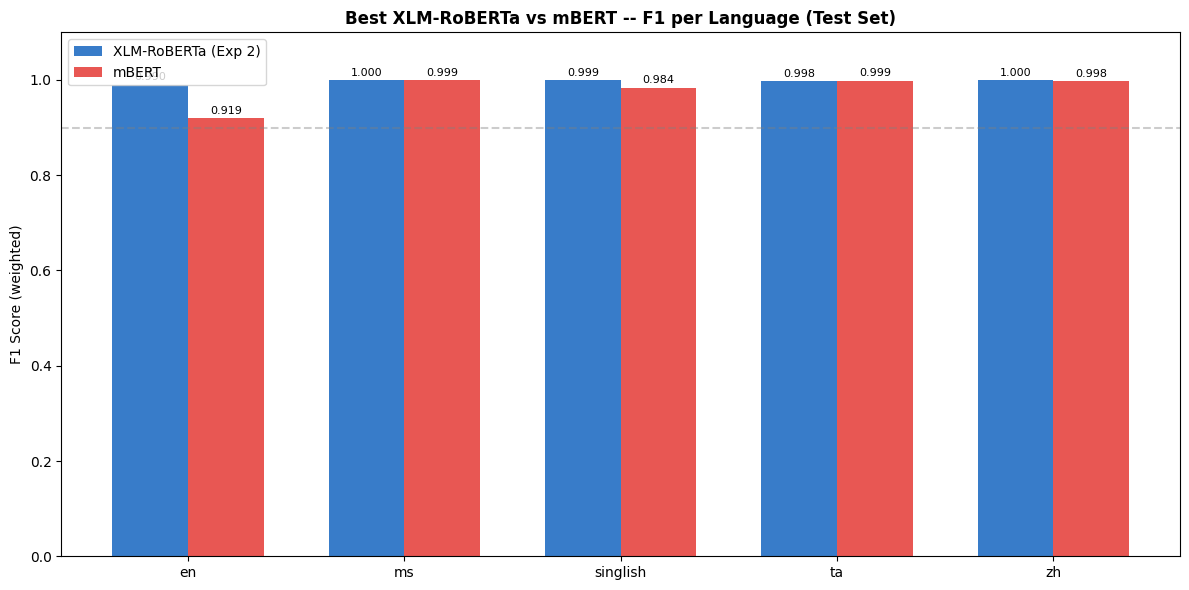

Saved: final_model_comparison_f1.png

Best model overall: XLM-RoBERTa (Exp 2)  (F1: 0.9927)


In [25]:
# =============================================================================
# CELL 12: Compare best XLM-RoBERTa variant vs mBERT -- table and F1 bar chart
# -----------------------------------------------------------------------------
df_best_xlm = df_xlm_all[df_xlm_all['experiment'] == best_xlm_experiment].copy()
df_best_xlm['model'] = f'XLM-RoBERTa ({best_xlm_experiment})'
df_mbert_test_labelled = df_mbert_test.copy()
df_mbert_test_labelled['model'] = 'mBERT'

df_all = pd.concat([df_best_xlm, df_mbert_test_labelled], ignore_index=True)

results_path = f'{OUTPUT_DIR}/final_model_comparison.csv'
df_all.to_csv(results_path, index=False)
print('Final comparison table (best XLM-RoBERTa variant vs mBERT):')
print(df_all[['model', 'language', 'accuracy', 'precision', 'recall', 'f1', 'auc']].to_string(index=False))
print(f"\nSaved: final_model_comparison.csv")

# F1 per language chart
df_lang   = df_all[df_all['language'] != 'overall'].copy()
languages = sorted(df_lang['language'].unique())
models    = df_lang['model'].unique()
x = np.arange(len(languages))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#1565C0', '#E53935']
for i, (model, color) in enumerate(zip(models, colors)):
    f1_vals = [
        df_lang[(df_lang['model'] == model) & (df_lang['language'] == lang)]['f1'].values[0]
        if len(df_lang[(df_lang['model'] == model) & (df_lang['language'] == lang)]) > 0 else 0
        for lang in languages
    ]
    bars = ax.bar(x + i*w - w/2, f1_vals, width=w, label=model, color=color, alpha=0.85)
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(languages)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score (weighted)')
ax.set_title('Best XLM-RoBERTa vs mBERT -- F1 per Language (Test Set)', fontweight='bold')
ax.legend()
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/final_model_comparison_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_model_comparison_f1.png')

# Best model overall -- compares by the 'model' label, which is unambiguous
# (this replaces the earlier buggy check that compared a display label like
# 'XLM-RoBERTa' against a run-name variable like 'xlmroberta-scamsense', which
# could never match)
df_overall      = df_all[df_all['language'] == 'overall']
best_model_name = df_overall.loc[df_overall['f1'].idxmax(), 'model']
best_f1         = df_overall['f1'].max()
print(f'\nBest model overall: {best_model_name}  (F1: {best_f1:.4f})')


## 12a. Summary comparison -- all experiments, one chart

A single scatter/dot chart summarising every experiment run in this notebook (5-config
sweep, WRS, text-norm, mBERT) on four key metrics at once: training accuracy, validation
accuracy, validation precision, and validation recall. This is the equivalent of the
'Comparing results' style chart used in the FPR/Viva slides -- one point per metric per
experiment, so all results can be read at a glance instead of scrolling through individual
sections.

Summary table (also saved as summary_comparison_all_experiments.csv):
    experiment  train_accuracy  val_accuracy  val_precision  val_recall
         Exp 1          0.9947        0.9920         0.9927      0.9926
         Exp 2          0.9964        0.9923         0.9927      0.9927
Exp 3 (winner)          0.9966        0.9932         0.9922      0.9922
           WRS          0.9974        0.9890         0.9887      0.9887
     Text-Norm          0.9962        0.9926         0.9918      0.9918
mBERT (frozen)          0.9177        0.9398         0.9407      0.9407


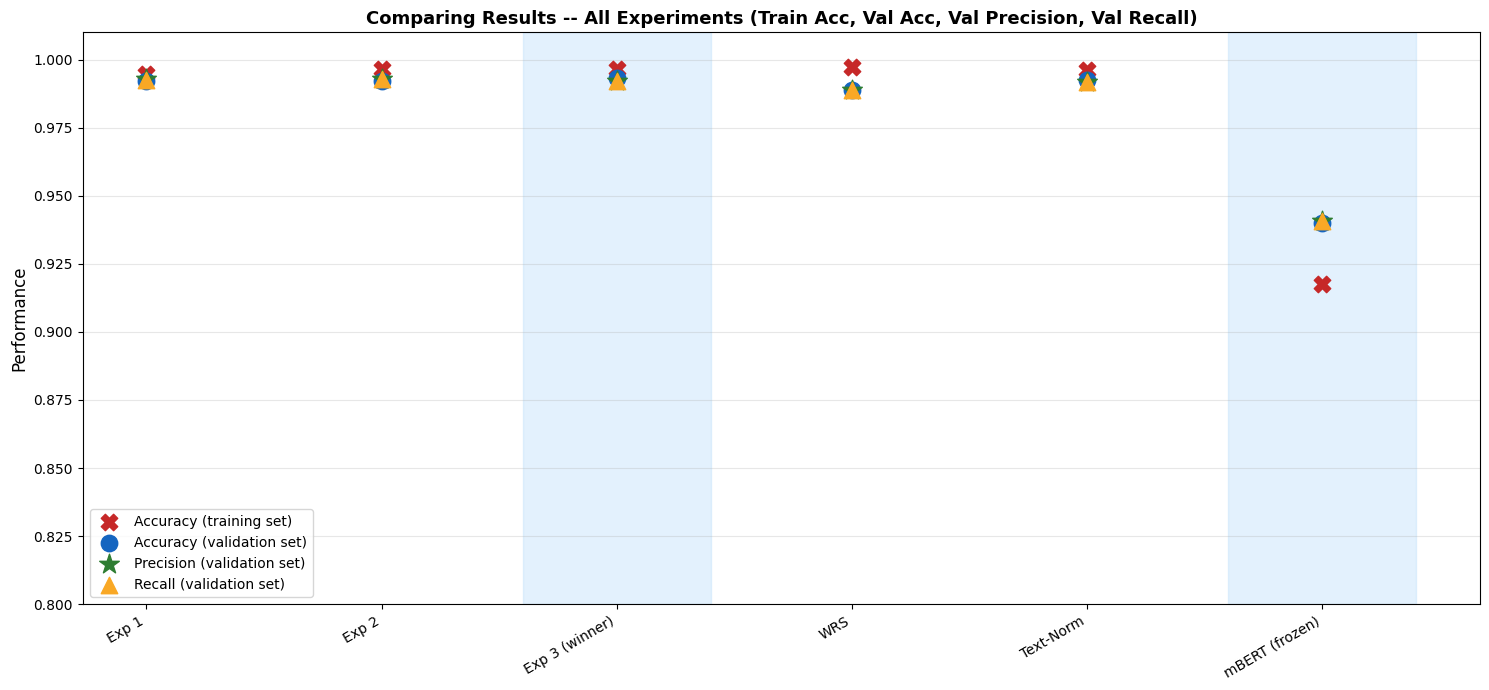

Saved: summary_comparison_all_experiments.png


In [26]:
# =============================================================================
# CELL 12a: Summary comparison chart -- all experiments, 4 key metrics
# -----------------------------------------------------------------------------
# Pulls train_acc / val_acc / val_f1 / val_precision / val_recall from each
# experiment's history + test results, already computed earlier in the notebook.
# No retraining required -- this only reads existing variables.
# =============================================================================

summary_rows = []

# -- 5-config sweep (Exp 1-5) --------------------------------------------------
for cfg in sweep_configs:
    label = cfg['label']
    h = sweep_histories[label]
    df_test_e = sweep_test_results[label]['df']
    val_prec = df_test_e[df_test_e['language'] == 'overall']['precision'].values[0]
    val_rec  = df_test_e[df_test_e['language'] == 'overall']['recall'].values[0]
    summary_rows.append({
        'experiment':       label + (' (winner)' if label == best_sweep_label else ''),
        'train_accuracy':   h['train_acc'][-1],
        'val_accuracy':     h['val_acc'][-1],
        'val_precision':    val_prec,
        'val_recall':       val_rec,
    })

# -- WRS --------------------------------------------------------------------
wrs_test_prec = df_wrs_test[df_wrs_test['language'] == 'overall']['precision'].values[0]
wrs_test_rec  = df_wrs_test[df_wrs_test['language'] == 'overall']['recall'].values[0]
summary_rows.append({
    'experiment':       'WRS',
    'train_accuracy':   wrs_history['train_acc'][-1],
    'val_accuracy':     wrs_history['val_acc'][-1],
    'val_precision':    wrs_test_prec,
    'val_recall':       wrs_test_rec,
})

# -- Text-Norm ----------------------------------------------------------------
norm_test_prec = df_norm_test[df_norm_test['language'] == 'overall']['precision'].values[0]
norm_test_rec  = df_norm_test[df_norm_test['language'] == 'overall']['recall'].values[0]
summary_rows.append({
    'experiment':       'Text-Norm',
    'train_accuracy':   norm_history['train_acc'][-1],
    'val_accuracy':     norm_history['val_acc'][-1],
    'val_precision':    norm_test_prec,
    'val_recall':       norm_test_rec,
})

# -- mBERT ----------------------------------------------------------------------
mbert_test_prec = df_mbert_test[df_mbert_test['language'] == 'overall']['precision'].values[0]
mbert_test_rec  = df_mbert_test[df_mbert_test['language'] == 'overall']['recall'].values[0]
summary_rows.append({
    'experiment':       'mBERT (frozen)',
    'train_accuracy':   mbert_history['train_acc'][-1],
    'val_accuracy':     mbert_history['val_acc'][-1],
    'val_precision':    mbert_test_prec,
    'val_recall':       mbert_test_rec,
})

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(f'{OUTPUT_DIR}/summary_comparison_all_experiments.csv', index=False)
print('Summary table (also saved as summary_comparison_all_experiments.csv):')
print(df_summary.round(4).to_string(index=False))

# -- Dot/scatter chart, styled after the FPR/Viva reference slide ----------------
fig, ax = plt.subplots(figsize=(15, 7))
x_pos = np.arange(len(df_summary))

ax.scatter(x_pos, df_summary['train_accuracy'], marker='X', s=140, color='#C62828',
           label='Accuracy (training set)', zorder=3)
ax.scatter(x_pos, df_summary['val_accuracy'],   marker='o', s=140, color='#1565C0',
           label='Accuracy (validation set)', zorder=3)
ax.scatter(x_pos, df_summary['val_precision'],  marker='*', s=220, color='#2E7D32',
           label='Precision (validation set)', zorder=3)
ax.scatter(x_pos, df_summary['val_recall'],     marker='^', s=140, color='#F9A825',
           label='Recall (validation set)', zorder=3)

# Highlight the winning sweep config + best overall model, matching the
# shaded-column style in the reference slide
highlight_labels = [f'{best_sweep_label} (winner)', 'mBERT (frozen)']
for lbl in highlight_labels:
    if lbl in df_summary['experiment'].values:
        idx = df_summary[df_summary['experiment'] == lbl].index[0]
        ax.axvspan(idx - 0.4, idx + 0.4, color='#BBDEFB', alpha=0.4, zorder=0)

ax.set_xticks(x_pos)
ax.set_xticklabels(df_summary['experiment'], rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Performance', fontsize=12)
ax.set_ylim(0.80, 1.01)
ax.set_title('Comparing Results -- All Experiments (Train Acc, Val Acc, Val Precision, Val Recall)',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/summary_comparison_all_experiments.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: summary_comparison_all_experiments.png')


## 13. Save best model + push to HuggingFace Hub

Selects the in-memory model object that corresponds to `best_model_name` (determined above),
saves it locally, and pushes it to HuggingFace Hub.


In [27]:
# =============================================================================
# CELL 13: Save best model to /kaggle/working + push to HuggingFace Hub
# -----------------------------------------------------------------------------
# HuggingFace Hub push creates a public model card at:
#   https://huggingface.co/Bhoovika/scamsense-xlmroberta
#   (or .../scamsense-mbert if mBERT wins)
# =============================================================================
from huggingface_hub import login

# Reload the winning model's weights into a fresh model object, selected by
# best_model_name (an unambiguous label from Section 12 -- 'mBERT' or
# 'XLM-RoBERTa (<experiment>)').
if best_model_name == 'mBERT':
    best_model, best_tokenizer = mbert_model, mbert_tokenizer
    best_ckpt_path, hf_model_id = MBERT_CKPT, 'Bhoovika/scamsense-mbert'
else:
    # Best model is one of the 5 XLM-RoBERTa variants -- reload its checkpoint
    if best_xlm_experiment == 'WRS':
        best_ckpt_path = WRS_CKPT
        best_tokenizer = wrs_tokenizer
    elif best_xlm_experiment == 'Text-Norm':
        best_ckpt_path = NORM_CKPT
        best_tokenizer = norm_tokenizer
    else:
        best_ckpt_path = sweep_checkpoints[best_xlm_experiment]['ckpt']
        best_tokenizer = sweep_checkpoints[best_xlm_experiment]['tokenizer']

    best_model = build_model(XLM_MODEL_NAME, freeze_encoder=False)
    best_model.load_state_dict(torch.load(best_ckpt_path))
    hf_model_id = 'Bhoovika/scamsense-xlmroberta'

best_model.eval()

# Save to /kaggle/working/models/scamsense_best_model/
save_path = f'{MODELS_DIR}/scamsense_best_model'
os.makedirs(save_path, exist_ok=True)
best_model.save_pretrained(save_path)
best_tokenizer.save_pretrained(save_path)
print(f'Model saved to: {save_path}')
print('Download from Kaggle output panel -> models/scamsense_best_model/')

# Push to HuggingFace Hub
try:
    HF_TOKEN = secrets.get_secret('HF_TOKEN')
    login(token=HF_TOKEN)
    best_model.push_to_hub(hf_model_id)
    best_tokenizer.push_to_hub(hf_model_id)
    print(f'Pushed to: https://huggingface.co/{hf_model_id}')
except Exception as e:
    print(f'HF push skipped -- add HF_TOKEN to Kaggle Secrets to enable.')
    print(f'Error: {e}')

print(f'\nNotebook 03 complete.')
print(f'Best model: {best_model_name} | F1: {best_f1:.4f}')
print(f'MLflow: https://dagshub.com/Bhoovika/ScamSense.mlflow')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/models/scamsense_best_model
Download from Kaggle output panel -> models/scamsense_best_model/


README.md: 0.00B [00:00, ?B/s]

...

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Pushed to: https://huggingface.co/Bhoovika/scamsense-xlmroberta

Notebook 03 complete.
Best model: XLM-RoBERTa (Exp 2) | F1: 0.9927
MLflow: https://dagshub.com/Bhoovika/ScamSense.mlflow
